# IBAnet: NMC spatial-scan test

Evaluate all 10,000 saved spectra against the same analytic ground truth as `compare_spatial_scan_soc.ipynb`. Outputs include elemental inventories, effective occupied-layer counts, spatial maps, and EDP comparisons.

**Export limitation:** this package returns only the posterior mean A=P*Y, not P or R. Presence and layer counts below are threshold-based estimates, not posterior probabilities. Ground truth uses ten numerical sublayers, including the Al holder; its discretization is not a unique physical layer count.

In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import sys, re, json, csv, zipfile, tomllib, hashlib, time
import tomli_w  # Install with: %pip install tomli-w
import onnxruntime as ort  # Install with: %pip install onnxruntime
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.fft import rfft, irfft, next_fast_len
from scipy.optimize import brentq
from tqdm.auto import tqdm
from IPython.display import display, Markdown

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "examples/generate_spatial_scan.py").is_file())
for directory in (ROOT, ROOT / "examples"):
    if str(directory) not in sys.path: sys.path.insert(0, str(directory))
import ibeamlab as ibl
import generate_spatial_scan as truth_model
BASE = ROOT / "examples/datasets/NMC_simulated"
DATA = BASE / "Data_NMC_simulated"
MODEL_PATH = BASE / "ibanet_10layers.zip"
OUT = BASE / "model_test/ibanet_results"
OUT.mkdir(exist_ok=True)
REBUILD_PREPROCESS_CACHE = False
Nthreads = 8
PREPROCESS_BATCH_SIZE = 512  # Bounds FFT working memory; inference uses the full scan.
MAX_SPECTRA = None  # None evaluates the complete scan; use 64 for a quick check.
ELEMENT_MIN_A = 100.0  # integrated elemental areal density, 1e15 atoms/cm2
ELEMENT_MIN_FRACTION = 0.001
LAYER_MIN_A = 100.0
LAYER_MIN_FRACTION = 0.001
DEPTH_LIMIT = 100_000.0
DEPTH_BINS = 100
PILEUP_ITERATIONS = 60
with zipfile.ZipFile(MODEL_PATH) as archive:
    manifest = tomllib.loads(archive.read("package.toml").decode())
spec = manifest["inverse"]
elements = tuple(spec["output_edp"]["elements"])
max_layers = spec["output_edp"]["max_layers"]
unit = spec["output_edp"]["unit"]
assert [(s["label"]) for s in spec["input_spectra"]] == ["RBS"]
reference_length = spec["input_spectra"][0]["length"]
reference = spec["setup_template"]["detectors"][0]
# Run the mean graph directly so interior zero rows remain visible for diagnostics.
with zipfile.ZipFile(MODEL_PATH) as archive:
    options = ort.SessionOptions()
    options.intra_op_num_threads = 4
    session = ort.InferenceSession(archive.read(manifest["model"]["onnx_file"]),
                                  sess_options=options, providers=["CPUExecutionProvider"])
assert manifest["transforms"]["input"]["type"] == "identity"
assert manifest["transforms"]["output"]["type"] == "constant_factor"
output_scale = manifest["transforms"]["output"]["factor"]
files = sorted(DATA.glob("*_RBS.dat"))
if MAX_SPECTRA is not None: files = files[:MAX_SPECTRA]
if not files: raise FileNotFoundError(DATA)
print(f"{len(files):,} spectra; elements={elements}; max layers={max_layers}; unit={unit}")
print("Physical input correction is explicit below; log/standardization and output scaling remain inside the package.")

10,000 spectra; elements=('Li', 'Ni', 'Mn', 'Co', 'O', 'C', 'F', 'P', 'Cu', 'Al'); max layers=10; unit=1e15 atoms/cm2
Physical input correction is explicit below; log/standardization and output scaling remain inside the package.


## Read spectra and correct acquisition effects

Real/live times come from each DAT header; calibration, beam, resolution and exposure come from `generate_spatial_scan.make_detectors`, which generated this scan. Do not substitute the training setup for the measured setup.

The exact pileup inverse can reject Poisson-noisy spectra. Here a projected fixed-point iteration approximately solves the native pileup equation, with nonnegative counts and a total inferred from the full measured tail. The forward residual is retained for inspection; this is not an exact statistical noise model. No clipping or cropping of the observed tail occurs before correction.

SIMNRA spectra may stop before the training grid ends. Under the full-tail assumption for this generated dataset, the odd-length measured spectrum has support 2N-1. After inversion, the N-channel spectrum is zero-padded to the training grid. This assumption must be revisited for cropped experimental spectra. The notebook asserts matching calibration and beam settings, applies reference/measured exposure scaling, then runs the ONNX graph. Embedded log/standardization runs once; the metadata output factor restores physical units. Direct ONNX execution retains interior zero rows that the native sample-structure validation rejects. Requires `onnxruntime` (install with `%pip install onnxruntime`).

Pileup subtraction runs in vectorized FFT batches grouped by spectrum length. The corrected full scan is then predicted in **one ONNX call**. The cell reports preprocessing and inference times separately; loading text files and pileup subtraction are not network inference.

Corrected inputs are cached for repeat evaluations. Cache validation uses preprocessing code/settings, generator code and each input file's name, size and modification time. Set `REBUILD_PREPROCESS_CACHE=True` to force fresh pileup subtraction.

`Nthreads = 8` runs spectrum loading and pileup subtraction concurrently across eight worker threads. Each worker handles a vectorized chunk and uses single-threaded FFTs to avoid nested thread pools. Results retain filename order.

In [2]:
def read_dat(path):
    with path.open() as stream:
        real = re.fullmatch(r"Real time: (\d+) us\s*", stream.readline())
        live = re.fullmatch(r"Live time: (\d+) us\s*", stream.readline())
        if real is None or live is None: raise ValueError(f"Invalid timing header: {path}")
        stream.readline()
        data = np.loadtxt(stream, ndmin=2)
    if not np.array_equal(data[:, 0], np.arange(len(data))): raise ValueError("Noncontiguous channels")
    counts = data[:, 1]
    if not np.isfinite(counts).all() or np.any(counts < 0): raise ValueError("Invalid counts")
    return counts, int(real[1]) / 1e6, int(live[1]) / 1e6


def noisy_pileup_inverse(counts, real, live, tau, iterations=PILEUP_ITERATIONS):
    if real <= 0 or live <= 0 or live > real: raise ValueError("Invalid acquisition times")
    if len(counts) % 2 != 1: raise ValueError("Expected full odd-length pileup spectrum")
    observed = np.asarray(counts, float) * real / live
    n = (len(observed) + 1) // 2
    z = observed.sum()
    if z == 0: return np.zeros(n), 0.0
    def h(total):
        rate = tau * total / real
        return rate * np.exp(-rate)
    total = brentq(lambda total: total * (1 - h(total)) - z,
                   z, z / (1 - np.exp(-1)))
    fraction = h(total)
    linear = 1 - 2 * fraction
    estimate = observed[:n].copy()
    estimate *= total / estimate.sum()
    for _ in range(iterations):
        convolution = fftconvolve(estimate, estimate)
        update = np.maximum((observed[:n] - fraction / total * convolution[:n]) / linear, 0)
        if update.sum() == 0: raise ValueError("Pileup correction collapsed")
        update *= total / update.sum()
        next_estimate = 0.5 * estimate + 0.5 * update
        change = np.abs(next_estimate - estimate).sum() / total
        estimate = next_estimate
        if change < 1e-8: break
    reconstructed = fraction / total * fftconvolve(estimate, estimate)
    reconstructed[:n] += linear * estimate
    residual = np.abs(reconstructed - observed).sum() / z
    return estimate, float(residual)


def noisy_pileup_inverse_batch(rows, real, live, tau):
    """Vectorized nonnegative inversion for spectra sharing full-tail length."""
    rows = np.asarray(rows, dtype=float)
    real, live = np.asarray(real), np.asarray(live)
    if np.any(real <= 0) or np.any(live <= 0) or np.any(live > real):
        raise ValueError("Invalid acquisition times")
    length = rows.shape[1]
    if length % 2 != 1: raise ValueError("Expected full odd-length pileup spectra")
    n = (length + 1) // 2
    observed = rows * (real / live)[:, None]
    z = observed.sum(axis=1)
    active = z > 0
    result = np.zeros((len(rows), n))
    residuals = np.zeros(len(rows))
    if not active.any(): return result, residuals
    obs, totals, times = observed[active], z[active], real[active]
    lower = totals.copy()
    upper = totals / (1 - np.exp(-1))
    for _ in range(55):
        mid = (lower + upper) / 2
        rate = tau * mid / times
        smaller = mid * (1 - rate * np.exp(-rate)) < totals
        lower = np.where(smaller, mid, lower)
        upper = np.where(smaller, upper, mid)
    total = (lower + upper) / 2
    rate = tau * total / times
    fraction = rate * np.exp(-rate)
    linear = 1 - 2 * fraction
    estimate = obs[:, :n].copy()
    if np.any(estimate.sum(axis=1) == 0): raise ValueError("Missing original spectrum support")
    estimate *= (total / estimate.sum(axis=1))[:, None]
    fft_length = next_fast_len(length)
    def convolution(a):
        transformed = rfft(a, n=fft_length, axis=1, workers=1)
        return irfft(transformed * transformed, n=fft_length, axis=1, workers=1)[:, :length]
    for _ in range(PILEUP_ITERATIONS):
        update = np.maximum((obs[:, :n] - (fraction / total)[:, None] *
                             convolution(estimate)[:, :n]) / linear[:, None], 0)
        sums = update.sum(axis=1)
        if np.any(sums == 0): raise ValueError("Pileup correction collapsed")
        update *= (total / sums)[:, None]
        next_estimate = 0.5 * estimate + 0.5 * update
        change = np.abs(next_estimate - estimate).sum(axis=1) / total
        estimate = next_estimate
        if np.max(change) < 1e-8: break
    reconstructed = (fraction / total)[:, None] * convolution(estimate)
    reconstructed[:, :n] += linear[:, None] * estimate
    result[active] = estimate
    residuals[active] = np.abs(reconstructed - obs).sum(axis=1) / totals
    return result, residuals


def prepare_all(paths):
    # These measured settings come from generate_spatial_scan.make_detectors.
    assert reference["particle"] == "H" and reference["beam_energy"] == 2974
    assert reference["beam_spread"] == 0 and reference["resolution"] == 20
    assert reference["calibration_linear"] == 2.63714 and reference["calibration_offset"] == 0
    assert reference["calibration_quadratic"] == 0
    if not spec["need_pileup_subtraction"]:
        raise ValueError("Review preprocessing: this dataset includes pileup")
    inputs = np.zeros((len(paths), reference_length), dtype=np.float32)
    residuals = np.zeros(len(paths))
    if not isinstance(Nthreads, int) or Nthreads < 1:
        raise ValueError("Nthreads must be a positive integer")

    def prepare_chunk(start):
        chunk = paths[start:start + PREPROCESS_BATCH_SIZE]
        records = [read_dat(path) for path in chunk]
        chunk_inputs = np.zeros((len(chunk), reference_length), dtype=np.float32)
        chunk_residuals = np.zeros(len(chunk))
        for length in sorted({len(record[0]) for record in records}):
            indices = [i for i, record in enumerate(records) if len(record[0]) == length]
            selected = [records[i] for i in indices]
            corrected, errors = noisy_pileup_inverse_batch(
                np.stack([r[0] for r in selected]), [r[1] for r in selected],
                [r[2] for r in selected], spec["pileup_fudge_factor_seconds"])
            corrected *= reference["particles_sr"] / 1e12
            if corrected.shape[1] > reference_length and np.any(corrected[:, reference_length:] > 1e-6):
                raise ValueError("Nonzero original counts outside training grid")
            width = min(corrected.shape[1], reference_length)
            chunk_inputs[indices, :width] = corrected[:, :width]
            chunk_residuals[indices] = errors
        return start, chunk_inputs, chunk_residuals

    starts = range(0, len(paths), PREPROCESS_BATCH_SIZE)
    # Each worker reads and corrects its own chunk. FFTs use one thread per worker
    # so eight workers do not create an additional nested FFT thread pool.
    with ThreadPoolExecutor(max_workers=Nthreads) as executor:
        completed = executor.map(prepare_chunk, starts)
        for start, corrected, errors in tqdm(completed, total=len(starts),
                desc=f"Read + subtract pileup ({Nthreads} threads)"):
            stop = start + len(corrected)
            inputs[start:stop] = corrected
            residuals[start:stop] = errors
    return inputs, residuals


def location(path):
    name = path.stem.removesuffix("_RBS")
    parts = name.rsplit("_", 4)
    return name, int(parts[1]) / 1e6, int(parts[3]) / 1e6


def ground_truth(x, y):
    fractions = truth_model.array_sublayer_compositions(x, y)
    result = np.zeros((max_layers, len(elements)))
    thickness = truth_model.sublayer_thicknesses()
    if len(thickness) > max_layers: raise ValueError("Ground truth exceeds model layer capacity")
    for j, e in enumerate(truth_model.ARRAY_ELEMENTS):
        if e not in elements: raise ValueError(f"Unsupported truth element: {e}")
        result[:len(thickness), elements.index(e)] = thickness * fractions[:, j]
    return result

In [3]:
started = time.perf_counter()
# Reuse only spectra that have already had pileup and acquisition corrections applied.
signature = hashlib.sha256()
signature.update(json.dumps(spec, sort_keys=True).encode())
signature.update(str(PILEUP_ITERATIONS).encode())
# Hash saved preprocessing source rather than transient Jupyter execution filenames.
notebook_document = json.loads((OUT.parent / "ibanet_test.ipynb").read_text(encoding="utf8"))
signature.update("".join(notebook_document["cells"][3]["source"]).encode())
signature.update(Path(truth_model.__file__).read_bytes())
for path in files:
    stat = path.stat()
    signature.update(f"{path.name}:{stat.st_size}:{stat.st_mtime_ns}".encode())
cache_key = signature.hexdigest()
cache_path = OUT / "pileup_subtracted_inputs.npz"
cache_used = False
if cache_path.exists() and not REBUILD_PREPROCESS_CACHE:
    with np.load(cache_path, allow_pickle=False) as cached:
        if str(cached["signature"].item()) == cache_key:
            inputs = cached["inputs"].copy()
            residuals = cached["residuals"].copy()
            cache_used = True
if not cache_used:
    inputs, residuals = prepare_all(files)
    np.savez_compressed(cache_path, signature=cache_key, inputs=inputs, residuals=residuals)
print("Loaded cached pileup-subtracted spectra" if cache_used else "Subtracted pileup and saved corrected spectra")
preprocessing_seconds = time.perf_counter() - started
print(f"Read + pileup subtraction: {preprocessing_seconds:.2f} s; inputs {inputs.shape}, {inputs.nbytes / 1e6:.1f} MB")
print(f"Pileup forward residual: median={np.median(residuals):.2%}, max={residuals.max():.2%}")

# One ONNX call for the entire scan. Large batches require more working memory.
started = time.perf_counter()
predicted = session.run([manifest["model"]["output_name"]],
                        {manifest["model"]["input_name"]: inputs})[0]
predicted = predicted.reshape(-1, max_layers, len(elements)) / output_scale
inference_seconds = time.perf_counter() - started
if predicted.shape != (len(files), max_layers, len(elements)) or not np.isfinite(predicted).all() or np.any(predicted < 0):
    raise ValueError("Invalid predicted EDPs")
print(f"Full-scan ONNX inference (one call): {inference_seconds:.2f} s")

started = time.perf_counter()
locations = [location(path) for path in files]
names = [row[0] for row in locations]
xy = np.asarray([(row[1], row[2]) for row in locations])
truth = np.asarray([ground_truth(x, y) for x, y in xy])
cell_ids = truth_model._array_cell_ids(xy[:, 0], xy[:, 1])
print(f"Ground-truth construction: {time.perf_counter() - started:.2f} s")
print(f"Electrode positions: {(cell_ids >= 0).sum():,}; holder: {(cell_ids < 0).sum():,}")

Read + subtract pileup (8 threads):   0%|          | 0/20 [00:00<?, ?it/s]

Subtracted pileup and saved corrected spectra
Read + pileup subtraction: 27.05 s; inputs (10000, 2997), 119.9 MB
Pileup forward residual: median=0.31%, max=0.42%
Full-scan ONNX inference (one call): 3.00 s
Ground-truth construction: 1.51 s
Electrode positions: 6,124; holder: 3,876


## Elements and effective layers

An element is detected when its integrated areal density exceeds both configured absolute and relative thresholds. A layer is occupied when its row sum passes analogous thresholds. Report both the number of occupied rows and the deepest occupied row: interior gaps are not silently removed. Thresholds are analysis choices, not trained probabilities; the sensitivity table shows their effect. All metrics use the unthresholded posterior mean unless explicitly stated.

In [4]:
def summarize(a, abs_element=ELEMENT_MIN_A, rel_element=ELEMENT_MIN_FRACTION,
              abs_layer=LAYER_MIN_A, rel_layer=LAYER_MIN_FRACTION):
    inventory = a.sum(axis=1)
    total = inventory.sum(axis=1)
    present = inventory > np.maximum(abs_element, rel_element * total[:, None])
    layer_totals = a.sum(axis=2)
    occupied = layer_totals > np.maximum(abs_layer, rel_layer * total[:, None])
    count = occupied.sum(axis=1)
    extent = np.max(np.where(occupied, np.arange(1, a.shape[1] + 1), 0), axis=1)
    return inventory, present, occupied, count, extent

pred_inventory, pred_present, occupied, layer_count, layer_extent = summarize(predicted)
true_inventory = truth.sum(axis=1)
true_present = true_inventory > 1e-8
true_layer_count = (truth.sum(axis=2) > 1e-8).sum(axis=1)

def table(headers, rows):
    display(Markdown("| " + " | ".join(headers) + " |\n| " + " | ".join(["---"] * len(headers)) + " |\n" +
                     "\n".join("| " + " | ".join(map(str, row)) + " |" for row in rows)))
rows = []
for j, e in enumerate(elements):
    tp = np.sum(pred_present[:, j] & true_present[:, j])
    fp = np.sum(pred_present[:, j] & ~true_present[:, j])
    fn = np.sum(~pred_present[:, j] & true_present[:, j])
    rows.append([e, int(true_present[:, j].sum()), int(pred_present[:, j].sum()),
                 f"{tp / max(tp + fp, 1):.3f}", f"{tp / max(tp + fn, 1):.3f}",
                 f"{np.mean(abs(pred_inventory[:, j] - true_inventory[:, j])):.1f}"])
table(["Element", "Truth positions", "Detected positions", "Precision", "Recall", "Inventory MAE"], rows)
table(["Relative layer threshold", "Mean occupied rows", "Matches ten truth sublayers (%)"],
      [[fraction, f"{summarize(predicted, rel_layer=fraction)[3].mean():.2f}",
        f"{100*np.mean(summarize(predicted, rel_layer=fraction)[3] == true_layer_count):.1f}"]
       for fraction in (0.0001, 0.001, 0.01)])

| Element | Truth positions | Detected positions | Precision | Recall | Inventory MAE |
| --- | --- | --- | --- | --- | --- |
| Li | 5817 | 4431 | 0.065 | 0.049 | 13934294.6 |
| Ni | 4596 | 3316 | 0.087 | 0.063 | 23554120.6 |
| Mn | 4596 | 8446 | 0.395 | 0.726 | 509859159.5 |
| Co | 4596 | 8229 | 0.412 | 0.737 | 534097217.1 |
| O | 4596 | 4914 | 0.164 | 0.176 | 49332540.3 |
| C | 1528 | 5811 | 0.147 | 0.559 | 92062134.5 |
| F | 0 | 1164 | 0.000 | 0.000 | 54552513.2 |
| P | 0 | 9975 | 0.000 | 0.000 | 1345541736.5 |
| Cu | 0 | 6875 | 0.000 | 0.000 | 1182620177.2 |
| Al | 3876 | 9750 | 0.398 | 1.000 | 423181158.0 |

| Relative layer threshold | Mean occupied rows | Matches ten truth sublayers (%) |
| --- | --- | --- |
| 0.0001 | 3.66 | 2.8 |
| 0.001 | 3.60 | 2.3 |
| 0.01 | 3.26 | 0.4 |

## Compare EDPs on physical depth

Direct layer-index errors are also reported, but predicted rows have variable thickness. The fairer profile comparison integrates each piecewise-constant composition onto shared areal-depth bins. Beyond a finite predicted stack, concentration is zero: no unreported extrapolation is applied. The ground-truth generator is reused at the rounded filename coordinates.

In [5]:
depth_edges = np.linspace(0, DEPTH_LIMIT, DEPTH_BINS + 1)
def depth_profile(a, edges=depth_edges):
    thickness = a.sum(axis=1)
    stack_edges = np.r_[0, np.cumsum(thickness)]
    fractions = np.divide(a, thickness[:, None], out=np.zeros_like(a, dtype=float),
                          where=thickness[:, None] > 0)
    overlap = np.maximum(0, np.minimum(edges[1:, None], stack_edges[None, 1:]) -
                         np.maximum(edges[:-1, None], stack_edges[None, :-1]))
    return (overlap @ fractions) / np.diff(edges)[:, None]

truth_profiles = np.asarray([depth_profile(a) for a in truth])
pred_profiles = np.asarray([depth_profile(a) for a in predicted])
metrics = {}
for label, mask in (("all", np.ones(len(files), bool)), ("electrodes", cell_ids >= 0), ("holder", cell_ids < 0)):
    if not mask.any(): continue
    metrics[label] = {
        "positions": int(mask.sum()),
        "layer_index_edp_mae": float(np.mean(abs(predicted[mask] - truth[mask]))),
        "element_inventory_mae": float(np.mean(abs(pred_inventory[mask] - true_inventory[mask]))),
        "depth_composition_mae_pp": float(100*np.mean(abs(pred_profiles[mask] - truth_profiles[mask]))),
        "total_areal_density_mae": float(np.mean(abs(pred_inventory[mask].sum(1) - true_inventory[mask].sum(1)))),
        "element_set_accuracy": float(np.mean(np.all(pred_present[mask] == true_present[mask], axis=1))),
        "occupied_layer_count_mae": float(np.mean(abs(layer_count[mask] - true_layer_count[mask]))),
    }
display(metrics)

{'all': {'positions': 10000,
  'layer_index_edp_mae': 42288285.845518626,
  'element_inventory_mae': 422873505.13941264,
  'depth_composition_mae_pp': 13.024505449288185,
  'total_areal_density_mae': 4228643089.392883,
  'element_set_accuracy': 0.0,
  'occupied_layer_count_mae': 6.4024},
 'electrodes': {'positions': 6124,
  'layer_index_edp_mae': 69051614.11600241,
  'element_inventory_mae': 690511017.9194555,
  'depth_composition_mae_pp': 18.137532348332623,
  'total_areal_density_mae': 6904966135.174036,
  'element_set_accuracy': 0.0,
  'occupied_layer_count_mae': 7.38847158719791},
 'holder': {'positions': 3876,
  'layer_index_edp_mae': 2779.5688306143848,
  'element_inventory_mae': 11758.94101687127,
  'depth_composition_mae_pp': 4.946028480828923,
  'total_areal_density_mae': 107915.92441567499,
  'element_set_accuracy': 0.0,
  'occupied_layer_count_mae': 4.844427244582043}}

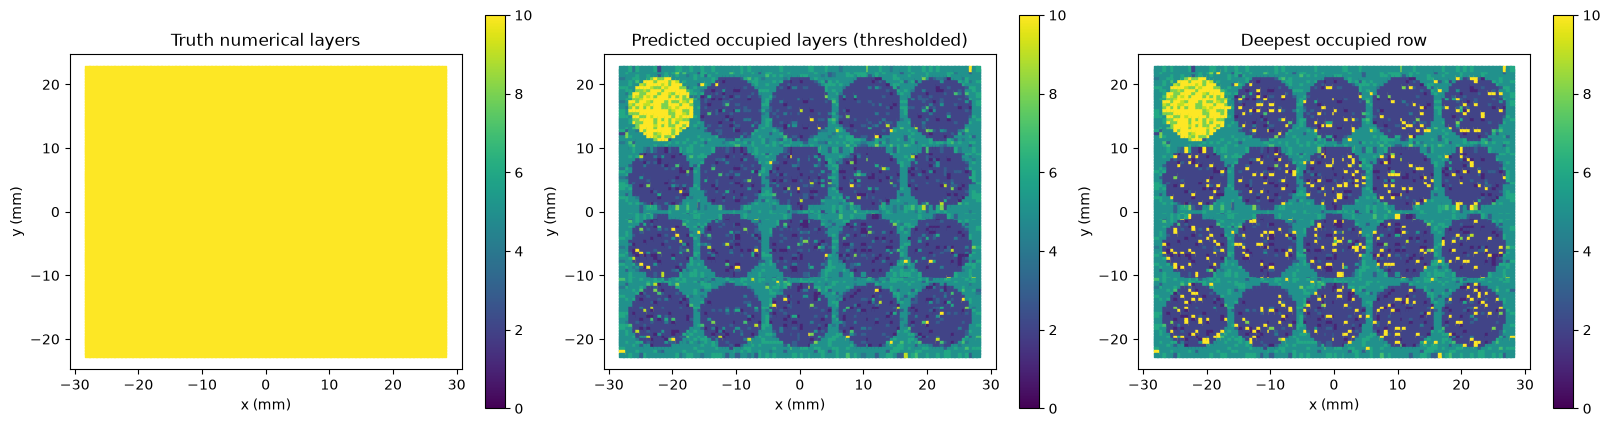

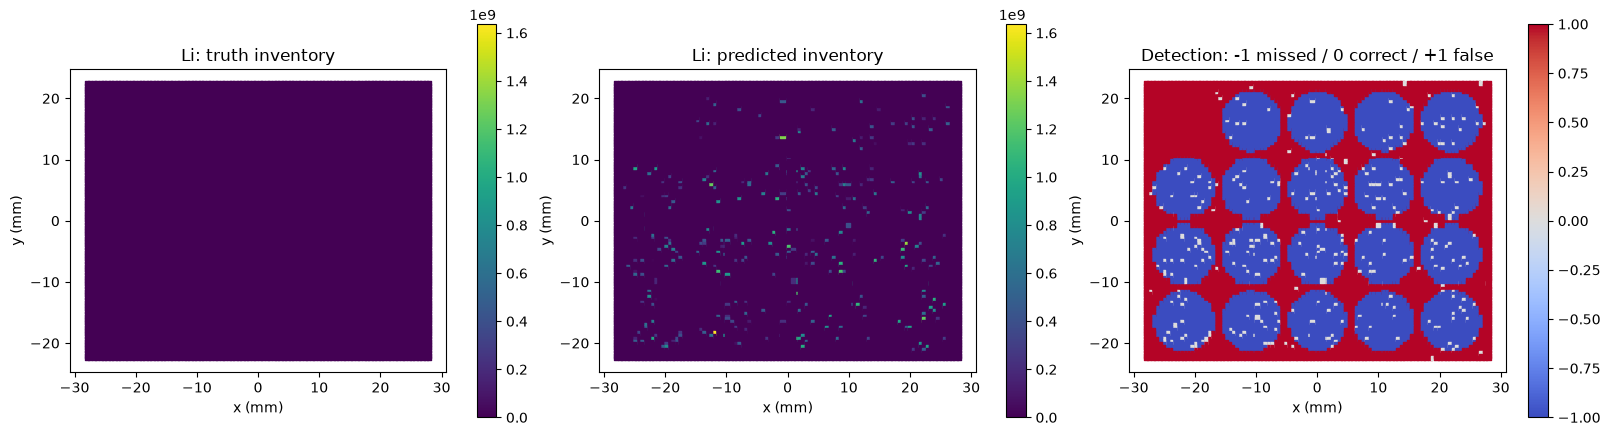

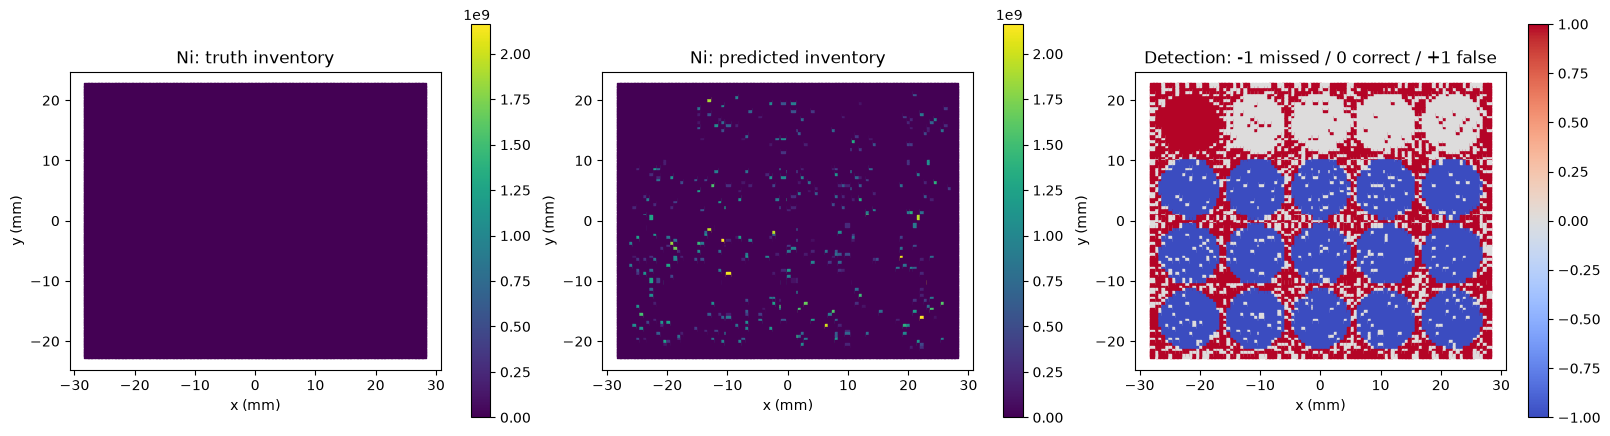

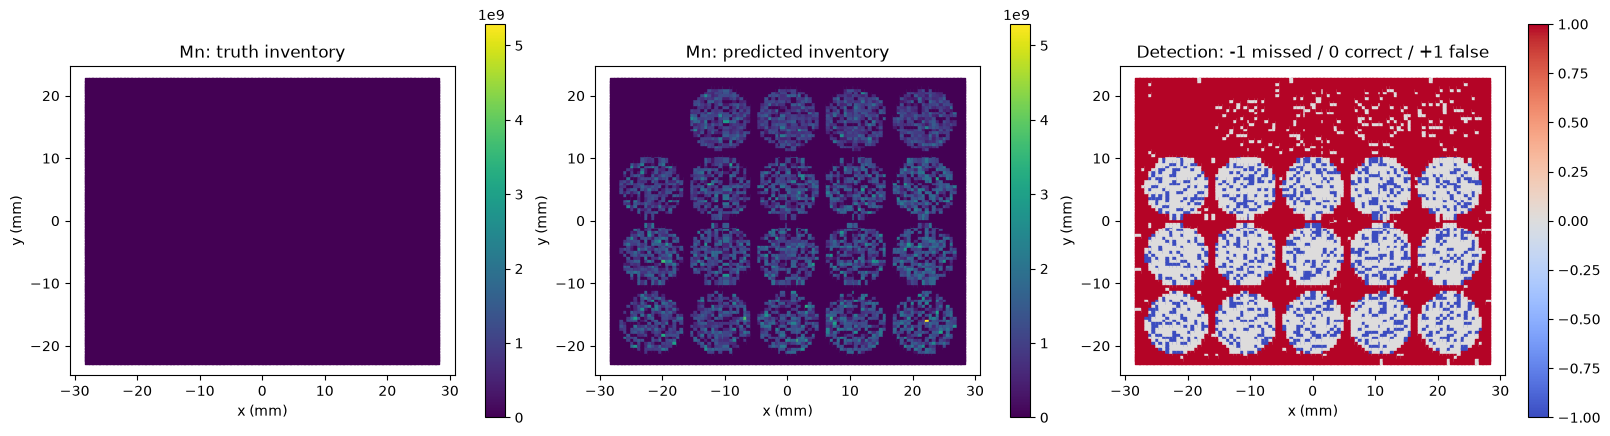

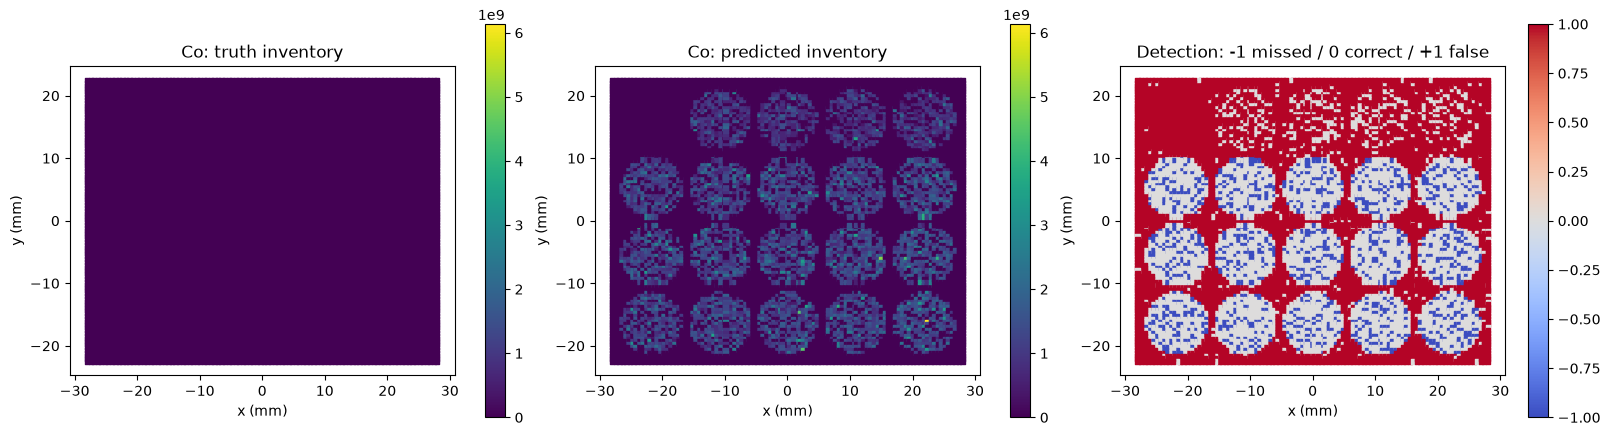

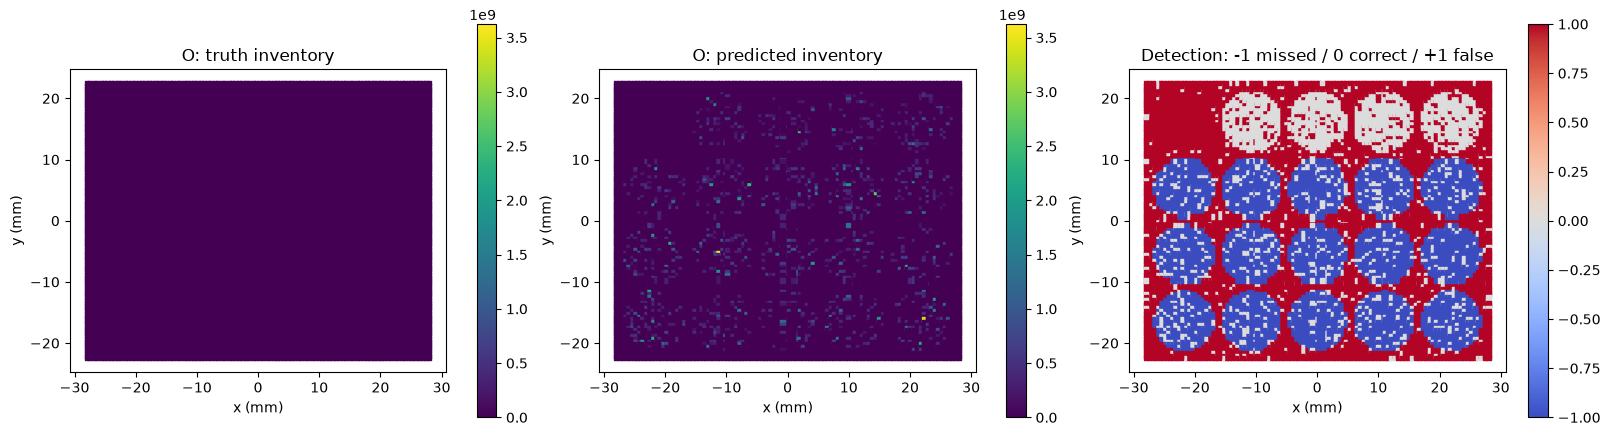

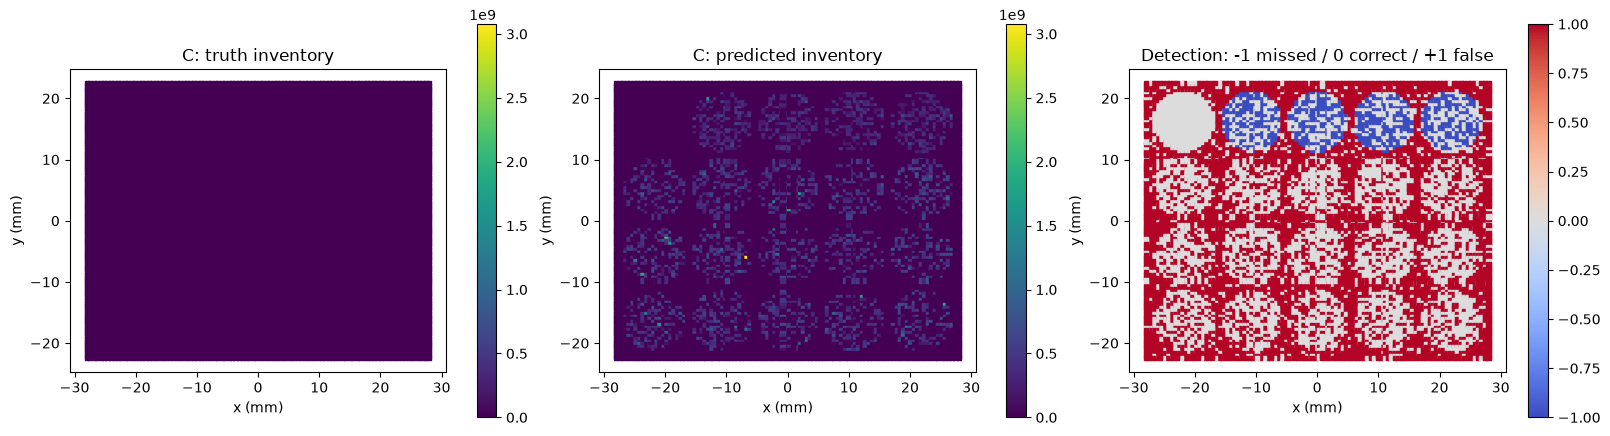

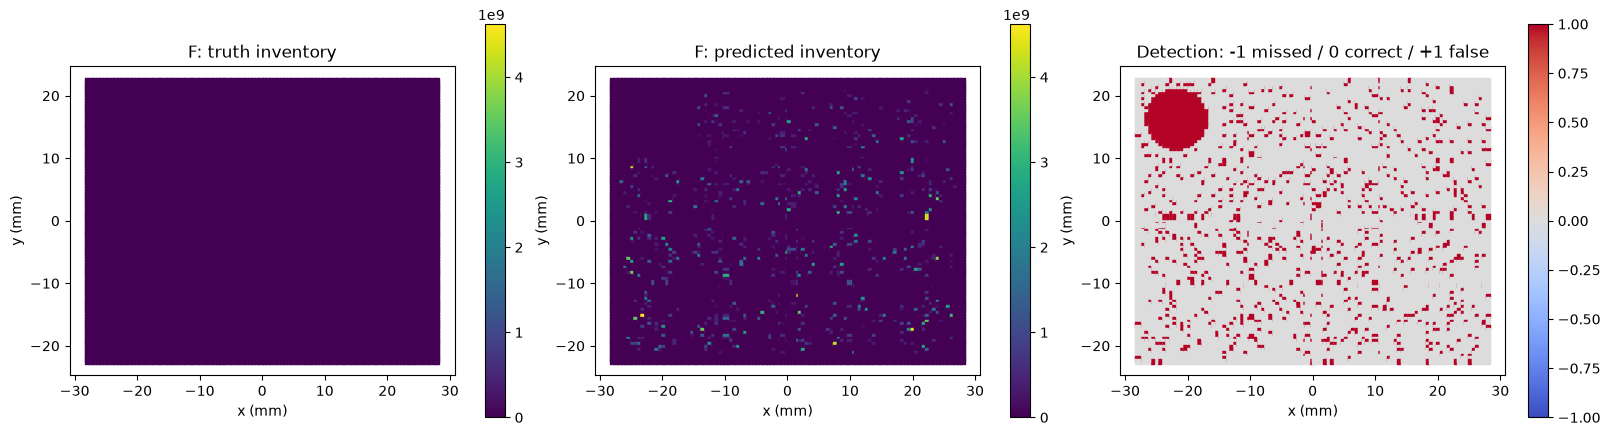

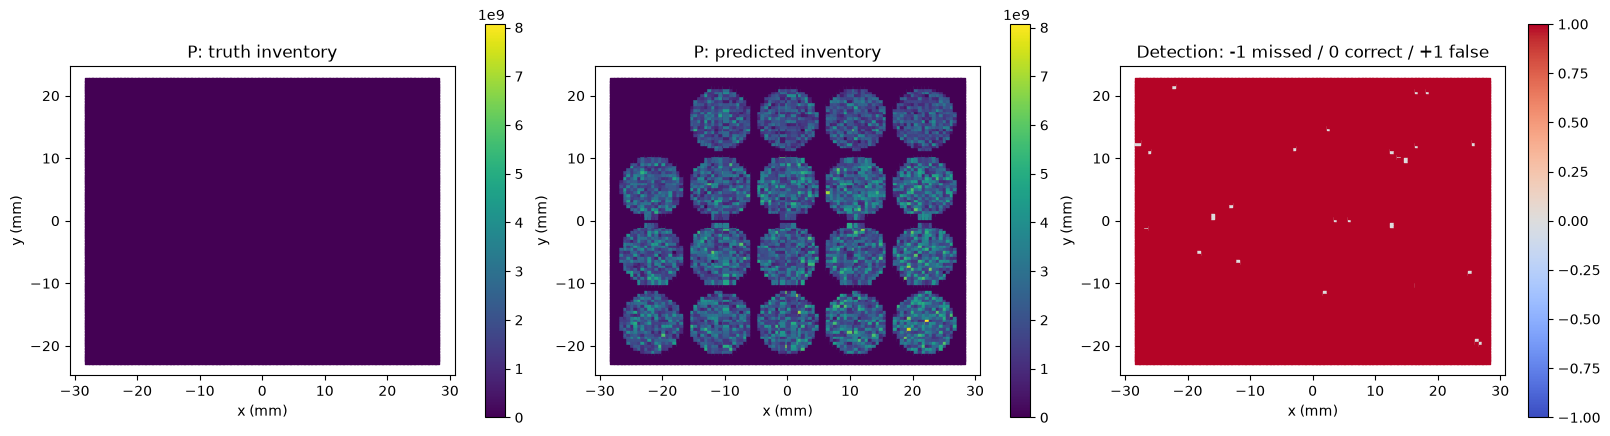

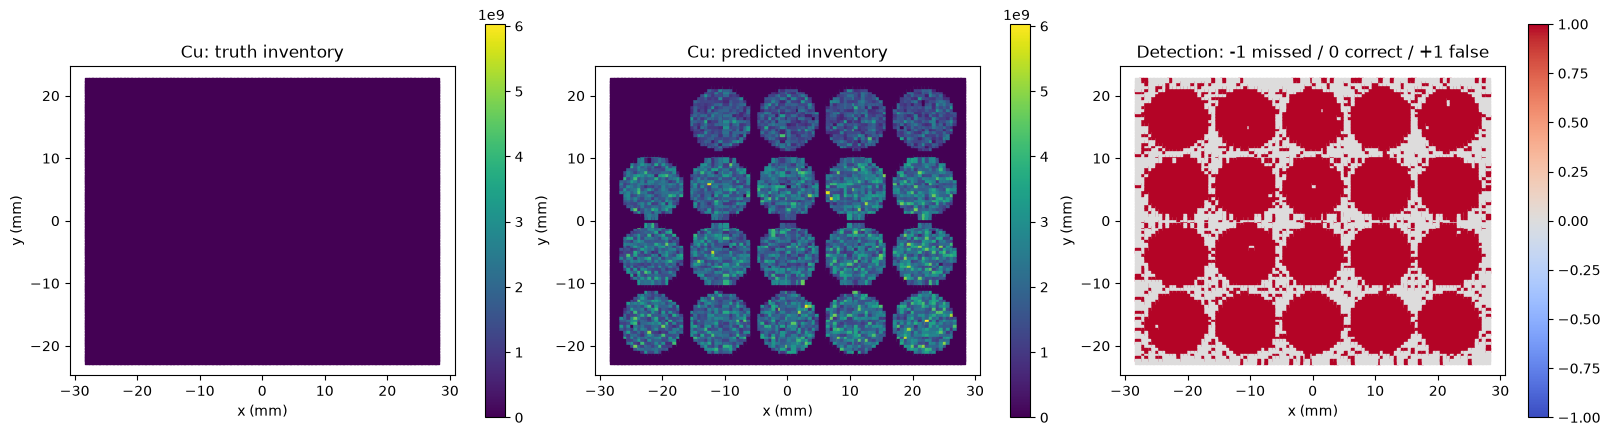

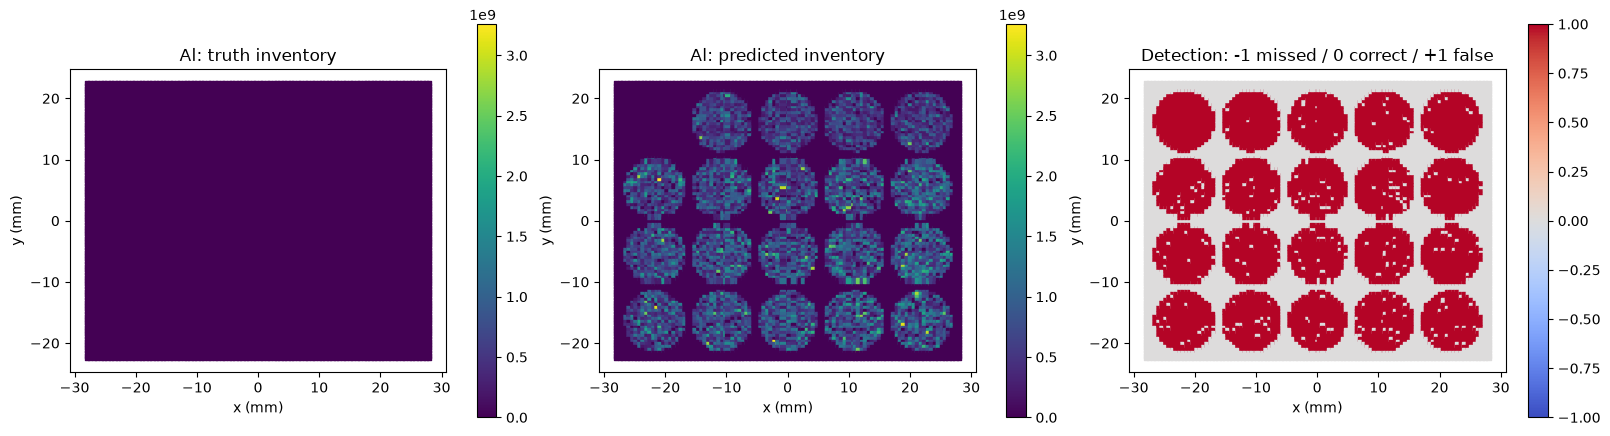

In [6]:
def spatial(ax, values, title, **kwargs):
    image = ax.scatter(xy[:, 0], xy[:, 1], c=values, marker="s", s=9, **kwargs)
    ax.set(title=title, xlabel="x (mm)", ylabel="y (mm)", aspect="equal")
    plt.colorbar(image, ax=ax, shrink=.8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
spatial(axes[0], true_layer_count, "Truth numerical layers", vmin=0, vmax=max_layers)
spatial(axes[1], layer_count, "Predicted occupied layers (thresholded)", vmin=0, vmax=max_layers)
spatial(axes[2], layer_extent, "Deepest occupied row", vmin=0, vmax=max_layers)
fig.savefig(OUT / "layer_count_maps.png", dpi=160)
plt.show()

for j, element in enumerate(elements):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    vmax = max(true_inventory[:, j].max(), pred_inventory[:, j].max(), 1)
    spatial(axes[0], true_inventory[:, j], f"{element}: truth inventory", vmin=0, vmax=vmax)
    spatial(axes[1], pred_inventory[:, j], f"{element}: predicted inventory", vmin=0, vmax=vmax)
    spatial(axes[2], pred_present[:, j].astype(int) - true_present[:, j].astype(int),
            "Detection: -1 missed / 0 correct / +1 false", cmap="coolwarm", vmin=-1, vmax=1)
    fig.savefig(OUT / f"element_{element}_maps.png", dpi=160)
    plt.show()

NMCcellarray_-282828_150_16590909_50: truth=['Li', 'C']; predicted=['Mn', 'Co', 'O', 'F', 'P', 'Cu']; occupied rows=2; extent=2


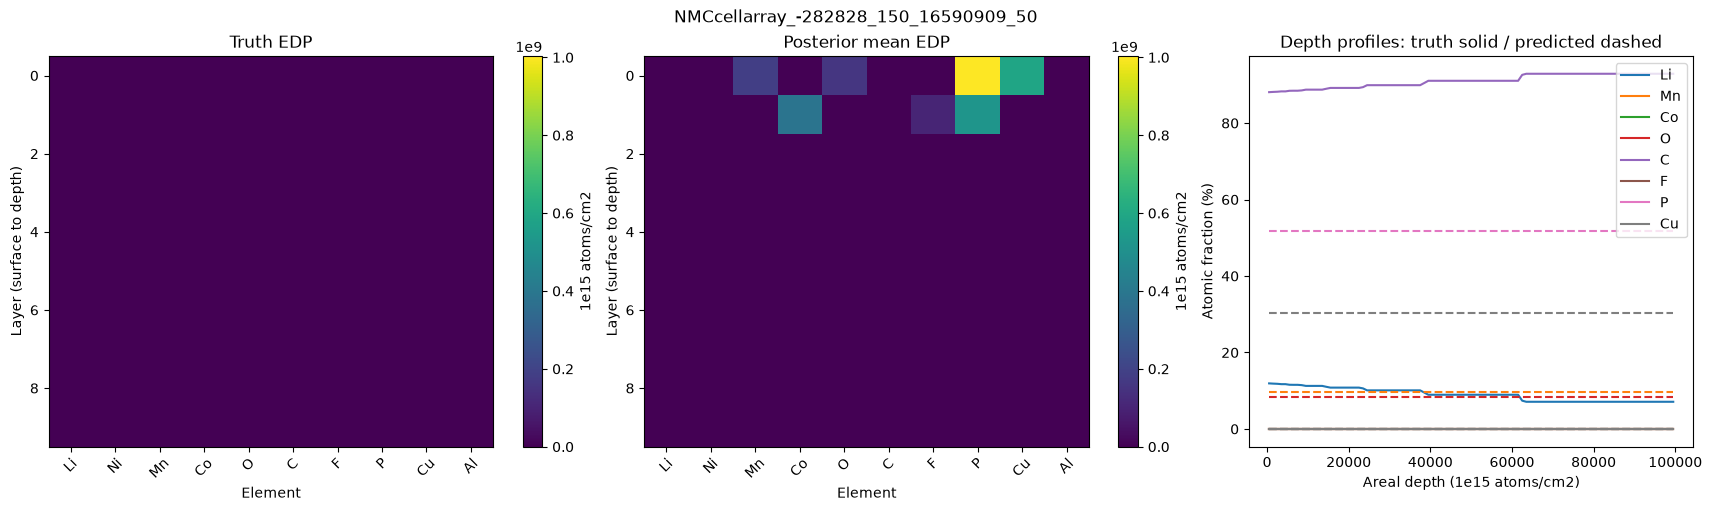

NMCcellarray_-282828_150_5681818_50: truth=['Li', 'Ni', 'Mn', 'Co', 'O']; predicted=['Mn', 'Co', 'C', 'P', 'Cu', 'Al']; occupied rows=2; extent=2


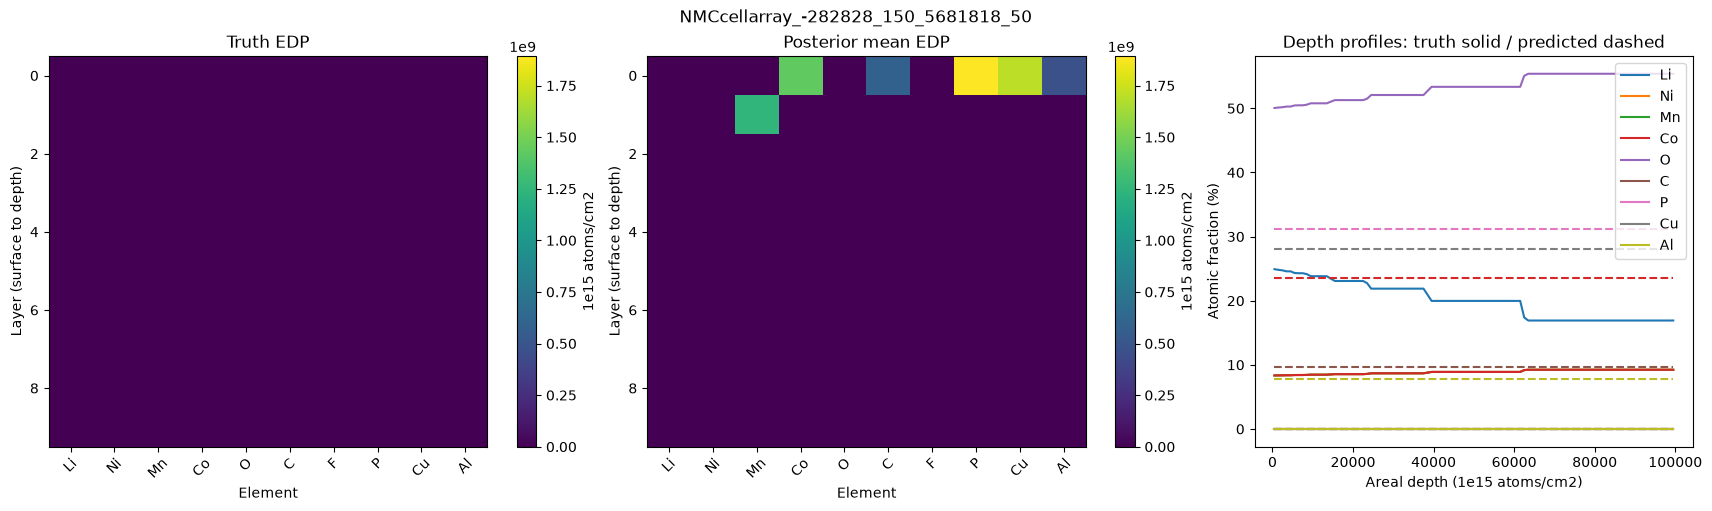

NMCcellarray_-282828_150_-5681818_50: truth=['Li', 'Ni', 'Mn', 'Co', 'O']; predicted=['Mn', 'Co', 'O', 'P', 'Cu', 'Al']; occupied rows=2; extent=2


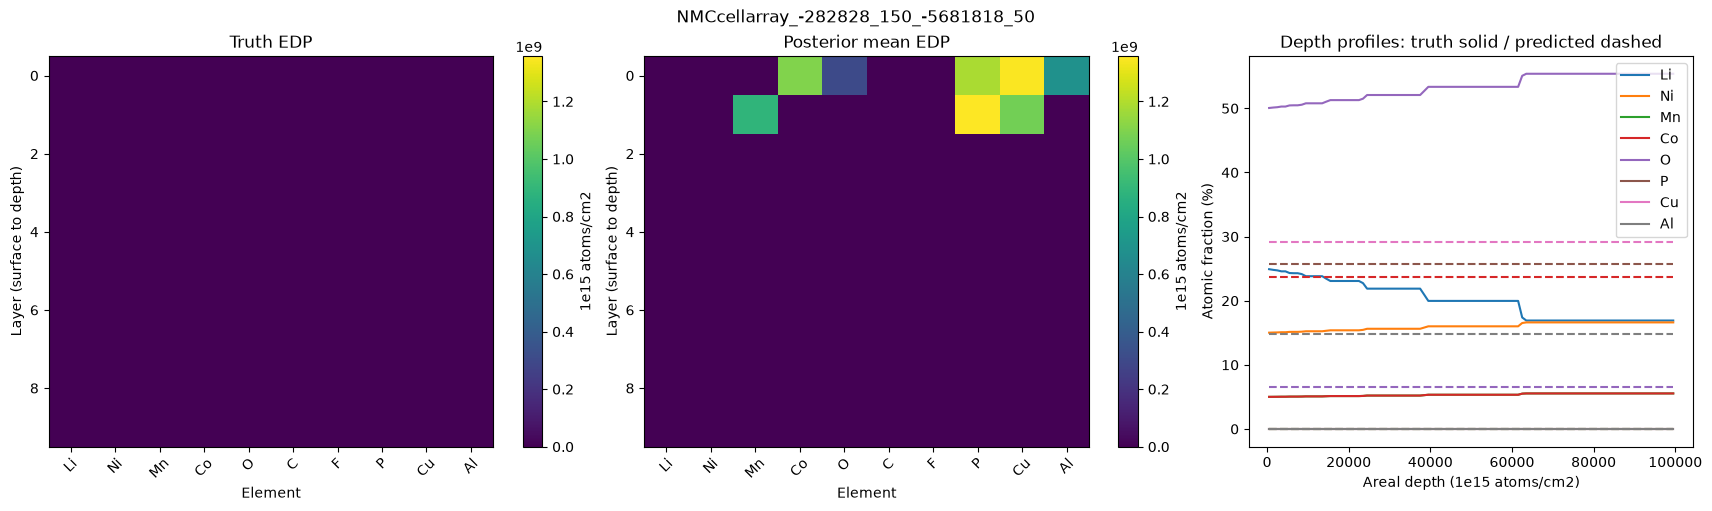

NMCcellarray_-282828_150_-16590909_50: truth=['Li', 'Ni', 'Mn', 'Co', 'O']; predicted=['Co', 'O', 'P', 'Cu', 'Al']; occupied rows=1; extent=1


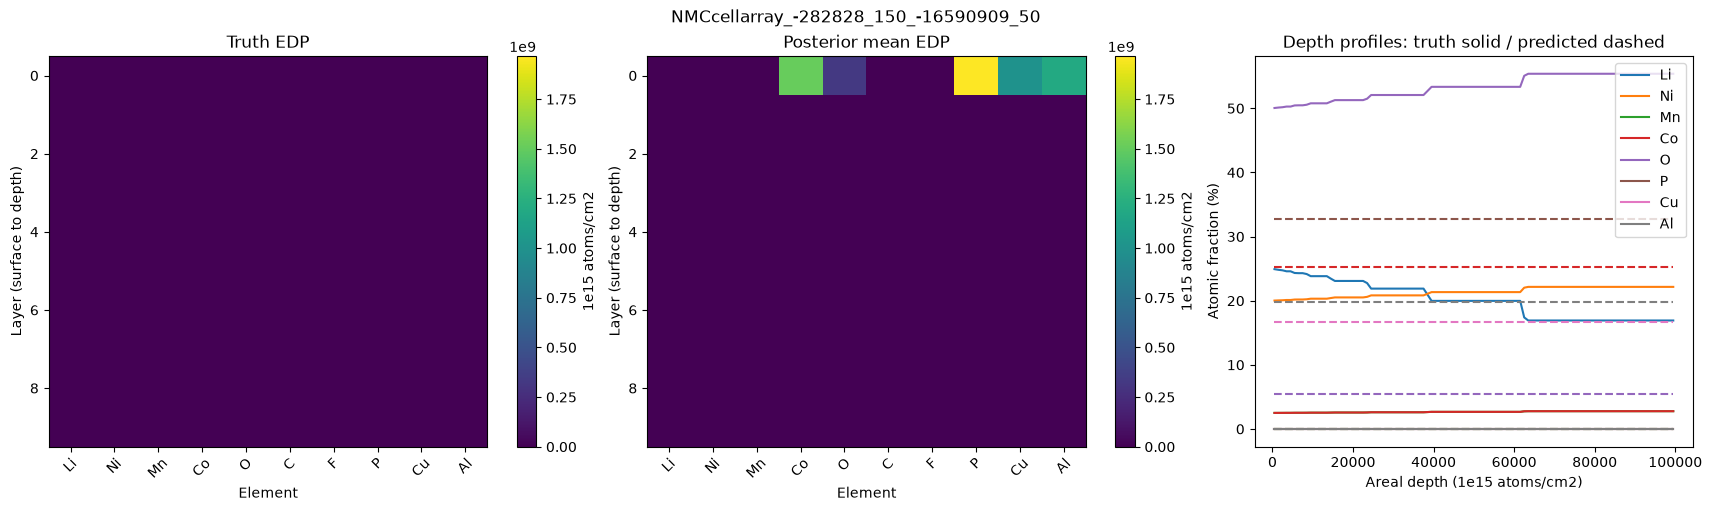

NMCcellarray_-10464646_150_-10681818_50: truth=['Al']; predicted=['Li', 'Mn', 'Co', 'O', 'C', 'P', 'Al']; occupied rows=5; extent=5


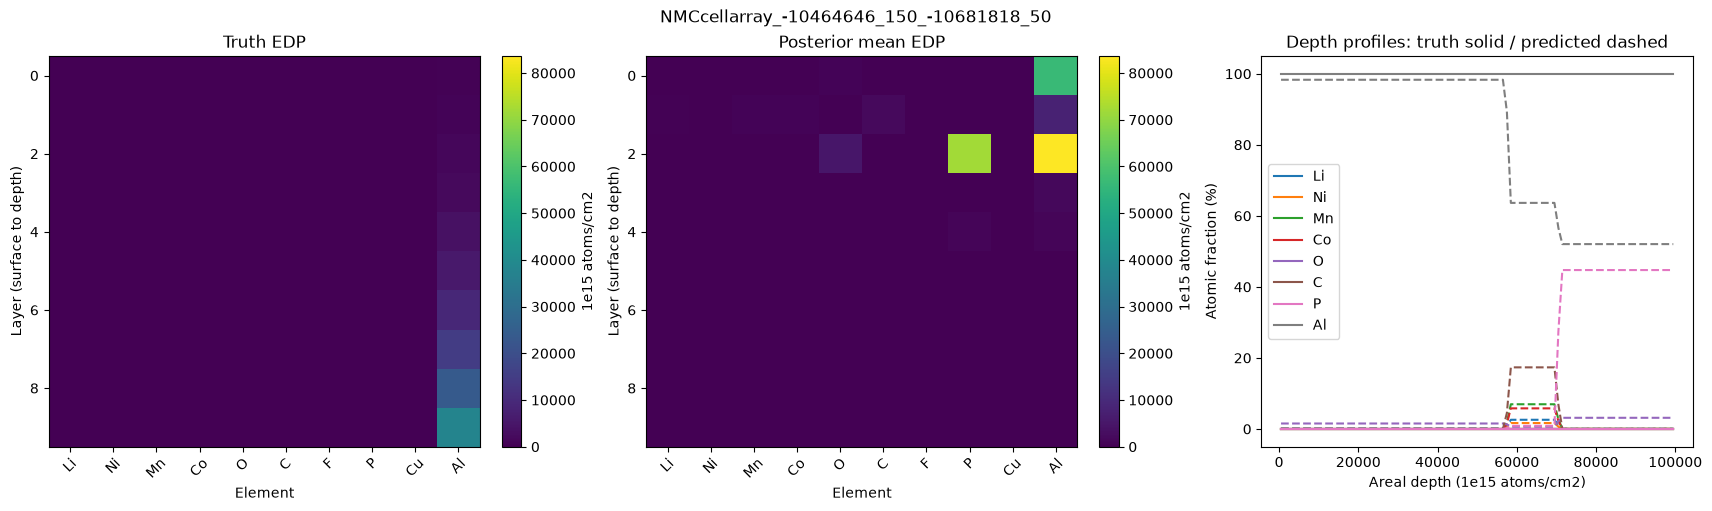

In [7]:
# Select the measured point nearest each chemistry/SOC representative plus a holder point.
representatives = [cell for cell in truth_model.array_cell_layout() if cell["column"] == 2]
selected = [int(np.argmin(np.sum((xy - [cell["center_x_mm"], cell["center_y_mm"]])**2, axis=1)))
            for cell in representatives]
if np.any(cell_ids < 0): selected.append(int(np.flatnonzero(cell_ids < 0)[0]))
selected = list(dict.fromkeys(selected))
# Add any index here to examine a particular scan location.
for index in selected:
    label = names[index]
    detected = [e for e, present in zip(elements, pred_present[index]) if present]
    actual = [e for e, present in zip(elements, true_present[index]) if present]
    print(f"{label}: truth={actual}; predicted={detected}; occupied rows={layer_count[index]}; extent={layer_extent[index]}")
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
    vmax = max(truth[index].max(), predicted[index].max(), 1)
    for ax, a, title in zip(axes[:2], (truth[index], predicted[index]), ("Truth EDP", "Posterior mean EDP")):
        im = ax.imshow(a, aspect="auto", vmin=0, vmax=vmax)
        ax.set_xticks(range(len(elements)), elements, rotation=45)
        ax.set(title=title, xlabel="Element", ylabel="Layer (surface to depth)")
        plt.colorbar(im, ax=ax, label=unit)
    midpoints = (depth_edges[:-1] + depth_edges[1:]) / 2
    for j, e in enumerate(elements):
        if max(true_inventory[index, j], pred_inventory[index, j]) < ELEMENT_MIN_A: continue
        line, = axes[2].plot(midpoints, 100*truth_profiles[index, :, j], label=e)
        axes[2].plot(midpoints, 100*pred_profiles[index, :, j], "--", color=line.get_color())
    axes[2].set(title="Depth profiles: truth solid / predicted dashed",
                xlabel=f"Areal depth ({unit})", ylabel="Atomic fraction (%)")
    axes[2].legend(); fig.suptitle(label)
    fig.savefig(OUT / f"edp_{index}.png", dpi=160)
    plt.show()

In [8]:
records = []
for i, name in enumerate(names):
    record = {"sample": name, "x_mm": xy[i, 0], "y_mm": xy[i, 1], "cell_id": int(cell_ids[i]),
              "truth_elements": ";".join(e for e, flag in zip(elements, true_present[i]) if flag),
              "predicted_elements": ";".join(e for e, flag in zip(elements, pred_present[i]) if flag),
              "truth_layers": int(true_layer_count[i]), "predicted_occupied_layers": int(layer_count[i]),
              "predicted_layer_extent": int(layer_extent[i]), "pileup_relative_l1_residual": float(residuals[i])}
    for j, e in enumerate(elements):
        record[f"truth_{e}_inventory"] = float(true_inventory[i, j])
        record[f"predicted_{e}_inventory"] = float(pred_inventory[i, j])
    records.append(record)
with (OUT / "positions.csv").open("w", newline="", encoding="utf8") as stream:
    writer = csv.DictWriter(stream, fieldnames=list(records[0]))
    writer.writeheader(); writer.writerows(records)
np.savez_compressed(OUT / "edp_comparison.npz", names=np.asarray(names), xy_mm=xy, elements=np.asarray(elements),
                    predicted=predicted, truth=truth, depth_edges=depth_edges,
                    predicted_profiles=pred_profiles, truth_profiles=truth_profiles,
                    pileup_residuals=residuals)
provenance = {"model_sha256": hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest(),
              "generator_sha256": hashlib.sha256(Path(truth_model.__file__).read_bytes()).hexdigest(),
              "preprocessing_cache_signature": cache_key,
              "preprocessing_cache_used": cache_used,
              "timing_seconds": {"preprocessing": preprocessing_seconds, "inference": inference_seconds},
              "thresholds": {"element_min_a": ELEMENT_MIN_A, "element_min_fraction": ELEMENT_MIN_FRACTION,
                             "layer_min_a": LAYER_MIN_A, "layer_min_fraction": LAYER_MIN_FRACTION},
              "pileup_iterations": PILEUP_ITERATIONS, "depth_limit": DEPTH_LIMIT, "depth_bins": DEPTH_BINS,
              "metrics": metrics}
(OUT / "metrics.json").write_text(json.dumps(provenance, indent=2), encoding="utf8")
print(f"Saved results and figures to {OUT}")

Saved results and figures to d:\iBeamLab\examples\datasets\NMC_simulated\model_test\ibanet_results


## Export inverse results as TOML

`ibanet_results/ibanet_results.toml` contains all scan positions, raw physical posterior-mean EDPs, ground-truth EDPs, threshold-derived elements and layer counts, pileup residuals, and provenance. The SOC comparison notebook reads this file directly. Requires `tomli-w`.

In [ ]:
def write_inverse_results(path):
    """Preserve raw posterior means; thresholds describe, but do not modify, EDPs."""
    results = []
    for i, name in enumerate(names):
        results.append({
            "sample": name, "x_mm": float(xy[i, 0]), "y_mm": float(xy[i, 1]),
            "cell_id": int(cell_ids[i]), "edp": predicted[i].astype(float).tolist(),
            "truth_edp": truth[i].astype(float).tolist(),
            "detected_elements": [e for e, flag in zip(elements, pred_present[i]) if flag],
            "truth_elements": [e for e, flag in zip(elements, true_present[i]) if flag],
            "occupied_layers": int(layer_count[i]), "layer_extent": int(layer_extent[i]),
            "truth_layers": int(true_layer_count[i]),
            "pileup_relative_l1_residual": float(residuals[i]),
        })
    document = {
        "format": "ibeamlab.inverse-scan-results", "format_version": 1,
        "model_name": "IBAnet", "prediction_kind": "posterior_mean",
        "unit": unit, "elements": list(elements), "max_layers": max_layers,
        "layer_order": "surface_to_depth", "layer_semantics": "variable_thickness",
        "pileup_subtracted": True, "live_time_corrected": True,
        "preprocessing_method": "nonnegative_projected_pileup_inverse",
        "pileup_fudge_factor_seconds": spec["pileup_fudge_factor_seconds"],
        "provenance": provenance, "positions": results,
    }
    temporary = path.with_suffix(".toml.tmp")
    with temporary.open("wb") as stream:
        tomli_w.dump(document, stream)
    temporary.replace(path)
    # Ensure the serialized matrix ordering and dimensions survive the round trip.
    with path.open("rb") as stream:
        restored = tomllib.load(stream)
    assert len(restored["positions"]) == len(names)
    assert restored["elements"] == list(elements)
    np.testing.assert_array_equal(np.asarray(restored["positions"][0]["edp"]), predicted[0])
    print(f"Saved {len(results):,} inverse results to {path}")

TOML_PATH = OUT / "ibanet_results.toml"
write_inverse_results(TOML_PATH)

## Counting-noise diagnosis

A controlled test bypassing scan preprocessing reproduces extreme predictions when Poisson noise is added to otherwise accurate clean SIMNRA inputs. This identifies severe model sensitivity to counting noise. It does not establish how the original training data were generated.

Run `python examples/diagnose_ibanet_noise.py` from the repository root to regenerate the report. It evaluates four electrode chemistries and an Al holder, with 16 draws at each noise amplitude. Fractional amplitudes interpolate toward Poisson draws for sensitivity analysis. No output clipping or spectrum smoothing is applied.


In [ ]:
noise_report = OUT / "noise_diagnosis.json"
if noise_report.exists():
    diagnosis = json.loads(noise_report.read_text(encoding="utf8"))
    if diagnosis["model_sha256"] != hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest():
        raise ValueError("Noise diagnosis belongs to a different model; regenerate it")
    table(["Sample", "Noise fraction", "Input relative L1 (%)", "Median predicted total", "True total"],
          [[r["sample"], r["noise_amplitude"], f"{100*r['input_relative_l1_median']:.3f}",
            f"{r['predicted_total_median']:.3g}", f"{r['truth_total']:.3g}"]
           for r in diagnosis["records"] if r["noise_amplitude"] in (0, 1)])
    display(__import__("IPython.display", fromlist=["Image"]).Image(filename=str(OUT / "noise_diagnosis.png")))
else:
    print("Run python examples/diagnose_ibanet_noise.py from the repository root first")
